In [1]:
import pandas as pd
import os,re,glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import LogLocator, FuncFormatter
import seaborn as sns
from scipy.stats import kruskal
from scipy.spatial.distance import braycurtis
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from itertools import combinations
from statsmodels.stats.multitest import multipletests

dates={"CW1A": "2024-07-25", "CW2A": "2024-08-01", "CW3A": "2024-08-07",
 "EXPUPS1A": "2024-07-25", "EXPUPS2A": "2024-08-01", "EXPUPS3A": "2024-08-07",
 "EXPMDS1B": "2024-07-25", "EXPMDS2B": "2024-08-01", 
 "EXPDWS1C": "2024-07-25", "EXPDWS2C": "2024-08-01", "EXPDWS3C": "2024-08-07",
 "PETUPS1A": "2024-07-25", "PETUPS2A": "2024-08-01", "PETUPS3A": "2024-08-07",
 
       "PETDWS2B": "2024-08-01", 
       "PETDWS2C": "2024-08-01", 
       
 "MBUPS1A": "2024-07-25", "MBUPS2A": "2024-08-01", "MBUPS3A": "2024-08-07",
 "MBMDS1B": "2024-07-25", "MBMDS2B": "2024-08-01", "MBMDS3B": "2024-08-07",
 "MBDWS1C": "2024-07-25", "MBDDWS2C": "2024-08-01", "MBDWS3C": "2024-08-07",
 "AJBUPS1A": "2024-07-25", "AJBUPS2A": "2024-08-01", "AJBUPS3A": "2024-08-07",
  "AJBMDS2B": "2024-08-01", "AJBMDS3B": "2024-08-07",
 "AJBDWS1C": "2024-07-25", "AJBDWS2C": "2024-08-01", "AJBDWS3C": "2024-08-07",
 "AJA1A": "2024-07-25", "AJA2A": "2024-08-01", "AJA3A": "2024-08-07"}


coords={"CW":(6.522984,3.310817), "EXP":(6.529435,3.316108),"PET":(6.540710,3.319277), "MB":(6.530166,3.316193), "MBD":(6.530166,3.316193),"AJB":(6.544360, 3.318868), "AJA":(6.537347,3.323543)}


alles=[]
MT=[]

med=[]
for f in glob.glob("*.report.txt"):
    if "NE.AACMFLCHV" not in f and "NTC" not in f:
        df=pd.read_csv(f,sep="\t", skiprows=2)
        df["sample"]=re.sub(".AACMFLCHV.1.cleaned_bbdukclean.report.txt", "", f)

        df['taxName'] = df['taxName'].str.strip()

        alles.append(df)

        med.append(df[0:2]["reads"].sum())
        
        bacteria_idx = df.index[df['taxName'] == 'Viruses']
    
        if len(bacteria_idx) == 0:
            subset = pd.DataFrame() 
        else:
            start_idx = bacteria_idx[0]
            end_idx = df.index[-1]  # fallback to last row
            bactsubset = df.loc[start_idx:end_idx]
            
            MT.append(bactsubset)
    
    
MTori=pd.concat(MT)
alles=pd.concat(alles)

In [3]:
pop_catchment={"EXP":1554771, "CW":1607903, "AJA":926846,  "MB": 1554572,"PET":533714, "AJB":527665}
area_sqkm={"EXP":56.059150, "CW":58.334600, "AJA": 19.292530, "MB": 56.051600, "PET":34.747900, "AJB":34.477040}


In [4]:
virdf=alles[alles["taxName"]=="Viruses"]
vird=dict(zip(virdf["sample"], virdf["reads"]))

for fam in ['Adenoviridae', 'Astroviridae', 'Picornaviridae', 'Caliciviridae', 'Parvoviridae', 'Polyomaviridae', 'Herpesviridae']:
    famdf=MTori[(MTori["rank"]=="family") & (MTori["taxName"]==fam) ]
    famdf["viral_reads"]=famdf["sample"].map(vird)
    famdf["prop"]=(famdf["reads"]/famdf["viral_reads"])*100
    print(fam,famdf["prop"].median())

Adenoviridae 21.60831509846827
Astroviridae 6.531243674956972
Picornaviridae 8.333333333333332
Caliciviridae 1.4633479212253828
Parvoviridae 0.23812111361016083
Polyomaviridae 0.2986643773833741
Herpesviridae 0.27036704152691615


In [5]:
two=alles[alles["taxName"]=="unclassified"]
hierso=alles[alles["rank"]=="superkingdom"]
hierso=pd.concat([hierso, two])
hierso["taxName"]=hierso["taxName"].str.replace("unclassified", "Unclassified")

In [6]:
np.mean(med)

7800695.685714286

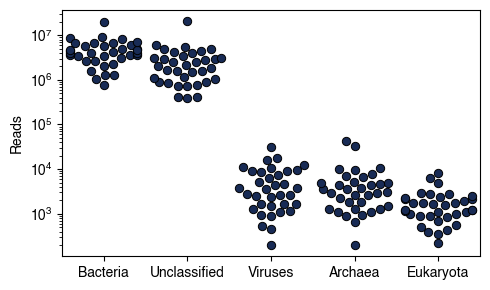

In [7]:


plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Helvetica"]

plot_df = hierso[hierso["reads"] > 0].copy()
tax_order = plot_df.groupby("taxName")["reads"].mean().sort_values(ascending=False).index

plt.figure(figsize=(5, 3))

sns.swarmplot(data=plot_df,x="taxName",y="reads",order=tax_order,size=6,color="#182b55",edgecolor="black",linewidth=0.7)

plt.yscale("log")
plt.xlabel("")
plt.ylabel("Reads")
plt.xticks( ha="center")

plt.tight_layout()


plt.show()

In [8]:
hierso[hierso["taxName"]=="Bacteria"]["%"].median()

61.83

In [9]:
hierso[hierso["taxName"]=="Unclassified"]["%"].median()

36.99

In [10]:
virdf=hierso[hierso["taxName"]=="Viruses"]
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")


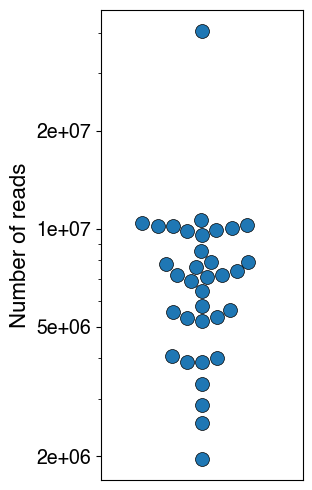

In [11]:
fig, ax = plt.subplots(figsize=(3, 5))
sns.swarmplot( data=tdf,y="num_seqs",size=10,edgecolor="black",linewidth=0.5,ax=ax)

ax.set_yscale("log")
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:g}"))
ax.set_xlabel("")
ax.set_xticks([])
ax.set_ylabel("Reads")
plt.tight_layout()

ax.set_ylabel("Number of reads", fontsize=16)
ax.tick_params(axis="y", which="both", labelsize=14)


plt.show()

In [12]:
rd=dict(zip(tdf['sample'], tdf['num_seqs']))
virdf["total"]=virdf["sample"].map(rd)
virdf["RPM_KU"]=(virdf["reads"]/virdf["total"])*1000000
esv_tdf=pd.read_csv("esv_read_counts_prefilter.csv")
esv_tdf["total"]=esv_tdf["sample_ID"].map(rd)
esv_tdf["RPM_ESV"]=(esv_tdf["read_count"]/esv_tdf["total"])*1000000
esv_tdf=esv_tdf.rename(columns={"sample_ID":"sample"})
merged_df=pd.merge(virdf[["sample", "RPM_KU"]],esv_tdf[["sample", "RPM_ESV"]], on="sample", how="outer")
merged_df["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in merged_df["sample"]]


In [13]:
esv_tdf["perc"]=(esv_tdf["read_count"]/esv_tdf["total"])*100
print(esv_tdf["perc"].min())
print(esv_tdf["perc"].max())

0.0025982429021507137
1.0125038651977203


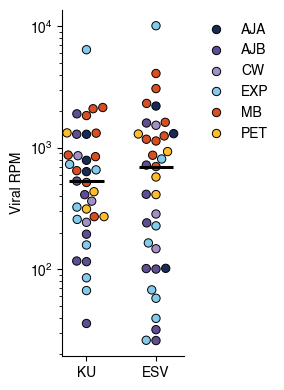

In [14]:
plot_df = merged_df.copy()
cols = [ "#182b55", "#5f4e94", "#a291c7", "#82cbec", "#d94f21", "#febd2b", "#9aab4b",]
canal_order = sorted(plot_df["canal"].dropna().unique())

canal_cols = {canal: cols[i % len(cols)] for i, canal in enumerate(canal_order)}
plot_long = plot_df.melt(id_vars=["canal"],value_vars=["RPM_KU", "RPM_ESV"],var_name="method",value_name="RPM")
plot_long = plot_long.dropna(subset=["RPM"])
plot_long = plot_long[plot_long["RPM"] > 0]

meth_order = ["RPM_KU", "RPM_ESV"]

fig, ax = plt.subplots(figsize=(3, 4))

sns.swarmplot( data=plot_long,x="method", y="RPM", order=meth_order,hue="canal",hue_order=canal_order,palette=canal_cols,size=6,edgecolor="black",linewidth=0.7, ax=ax)

for i, method in enumerate(meth_order):
    median_val = plot_long.loc[
        plot_long["method"] == method, "RPM"
    ].median()

    ax.hlines(y=median_val,xmin=i - 0.25,  xmax=i + 0.25, color="black", linewidth=2.2, zorder=5)

ax.set_yscale("log")

ax.set_xlabel("")
ax.set_ylabel("Viral RPM")

ax.set_xticklabels(["KU", "ESV"])

ax.legend( title="", frameon=False, bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()

plt.tight_layout()

plt.show()

In [17]:
rpm_cols = ["RPM_KU", "RPM_ESV"]

res = []

for col in rpm_cols:
    test_df = merged_df[["canal", col]].dropna().copy()
    groups = [group[col].values for _, group in test_df.groupby("canal") if len(group[col].dropna()) > 0 ]
    canals = [ canal for canal, group in test_df.groupby("canal")  if len(group[col].dropna()) > 0]
    
    stat, pval = kruskal(*groups)
    res.append({ "variable": col, "n_canals": len(groups),"canals_tested": ", ".join(canals), "kruskal_H": stat,  "p_value": pval })

rpm_res = pd.DataFrame(res)


rpm_res

,variable,n_canals,canals_tested,kruskal_H,p_value
0,RPM_KU,6,"AJA, AJB, CW, EXP, MB, PET",7.631614,0.177741
1,RPM_ESV,6,"AJA, AJB, CW, EXP, MB, PET",12.740873,0.025932


In [18]:
summ = merged_df.groupby("canal")[["RPM_KU", "RPM_ESV"]].agg(["count", "median", "mean"])

summ

RPM_KU                          RPM_ESV                          
       count      median         mean   count       median         mean
canal                                                                  
AJA        3  790.610096   907.753949       3  1310.208860  1207.733514
AJB        8  303.574908   576.597099       8   171.624782   405.256734
CW         3  364.550311   490.250026       3   285.825414   656.564003
EXP        8  291.896426  1089.214260       8   116.490989  1440.088782
MB         9  873.419861  1175.576983       9  1254.482338  1807.499505
PET        4  375.128118   587.811532       4   754.664400   806.111631

In [21]:
MT=MTori[(MTori["taxReads"]>=10) & (MTori["kmers"]>=660)]

In [22]:
tax_counts = MT[MT["rank"]=="species"].groupby("sample")["taxName"].count().reset_index(name="n_taxName")
median_taxName_per_sample = tax_counts["n_taxName"].median()
print("Median taxName count per sample:", median_taxName_per_sample)

Median taxName count per sample: 6.0


In [23]:
tdf=pd.read_csv("read_counts_seqkit.csv")
tdf["sample"]=tdf["file"].str.replace(".AACMFLCHV.1.cleaned_bbdukclean_R1.fastq.gz", "")
tdf["millions"]=round(tdf["num_seqs"]/1000000, 0)
tdf["kmerthreshold"]=tdf["millions"]*660
tdf["kmerthreshold_strict"]=tdf["millions"]*1300
kmer=dict(zip(tdf["sample"], tdf["kmerthreshold"]))
kmer_strict_d=dict(zip(tdf["sample"], tdf["kmerthreshold_strict"]))


In [24]:
tdf["num_seqs"].median()

7195166.0

In [26]:
len(MT[MT["rank"]=="family"]["taxName"].unique())

20

In [27]:
len(MT[MT["rank"]=="genus"]["taxName"].unique())

84

In [28]:
len(MT[MT["rank"]=="species"]["taxName"].unique())

88

In [29]:
others=['Hibiscus latent Fort Pierce virus', 'Pepper mild mottle virus', 'Wenzhou picorna-like virus 47', 'Tobacco mild green mosaic virus',  'Tobacco mosaic virus',    'Tobacco latent virus']


In [30]:
rr=dict(zip(tdf["sample"], tdf["num_seqs"]))

In [31]:

##UNBFILETERED COUNTS
pp=alles[alles["taxName"].str.contains("Pepper mild mottle virus")]
pp["total_reads"]=pp["sample"].map(rr)
pp["RPM"]=(pp["taxReads"]/pp["total_reads"])*1000000
ppdf=pp[["sample", "RPM"]].rename(columns={"RPM":"PMMV_RPM"})

In [32]:
##UNBFILETERED COUNTS
crass=alles[alles["taxName"].str.contains("crAssphage")]
crass_sum = crass.groupby("sample", as_index=False)["taxReads"].sum().rename(columns={"taxReads": "crAssphage_reads"})
crass_sum["total_reads"]=crass_sum["sample"].map(rr)
crass_sum["RPM"]=(crass_sum["crAssphage_reads"]/crass_sum["total_reads"])*1000000
crassdf=crass_sum[["sample", "RPM"]].rename(columns={"RPM":"crAss_RPM"})

In [33]:
tm=alles[alles["taxName"].str.contains("Tobacco mosaic virus")]
tm["total_reads"]=tm["sample"].map(rr)
tm["RPM"]=(tm["taxReads"]/tm["total_reads"])*1000000
tmdf=tm[["sample", "RPM"]].rename(columns={"RPM":"TM_RPM"})

In [34]:
indidf=pd.merge(ppdf, crassdf, on="sample")
# indidf=pd.merge(indidf, tmdf, on="sample")

In [35]:
indidf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in indidf["sample"]]

In [36]:
##UNBFILETERED COUNTS

esvdf=pd.read_csv("PPdf_esv.csv").rename(columns={"sample_ID":"sample"})
esvdf["total_reads"]=esvdf["sample"].map(rr)
esvdf["RPM"]=(esvdf["read_count"]/esvdf["total_reads"])*1000000
esvpppdf=esvdf[["sample", "RPM"]].rename(columns={"RPM":"PPMV_RPM_ESV"})

In [37]:
indidf=pd.merge(indidf,esvpppdf, on="sample")

In [38]:

canal_order = sorted( pop_catchment, key=pop_catchment.get, reverse=True)


In [39]:
indidf["pop"]=indidf["canal"].map(pop_catchment)

In [42]:
from scipy.stats import spearmanr, pearsonr
df=indidf.copy()
m_cols = ["PMMV_RPM", "crAss_RPM", "PPMV_RPM_ESV", "pop"]
for col in m_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

res = []
for m in ["PMMV_RPM", "crAss_RPM", "PPMV_RPM_ESV"]:
    tmp = df[[m, "pop"]].dropna()
    rho, p_spear = spearmanr(tmp["pop"], tmp[m])
    r, p_pear = pearsonr(tmp["pop"], tmp[m])
    res.append({ "level": "sample", "marker": m,"n": len(tmp), "spearman_rho": rho,"spearman_p": p_spear,"pearson_r": r, "pearson_p": p_pear})
sample_corr = pd.DataFrame(res)

canal_df = df.groupby("canal", as_index=False).agg({"PMMV_RPM": "mean", "crAss_RPM": "mean", "PPMV_RPM_ESV": "mean", "pop": "first"})

rr = []
for m in ["PMMV_RPM", "crAss_RPM", "PPMV_RPM_ESV"]:
    tmp = canal_df[[m, "pop"]].dropna()
    rho, p_spear = spearmanr(tmp["pop"], tmp[m])
    r, p_pear = pearsonr(tmp["pop"], tmp[m])

    rr.append({ "level": "canal_mean", "marker": m, "n": len(tmp), "spearman_rho": rho,"spearman_p": p_spear, "pearson_r": r, "pearson_p": p_pear })

canal_corr = pd.DataFrame(rr)
corr_rr =pd.concat([sample_corr, canal_corr], ignore_index=True)
corr_rr

,level,marker,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,sample,PMMV_RPM,27,-0.071731,0.722181,-0.056500,0.779542
1,sample,crAss_RPM,27,0.269620,0.173818,0.208220,0.297308
2,sample,PPMV_RPM_ESV,27,-0.048764,0.809136,0.055909,0.781793
3,canal_mean,PMMV_RPM,6,-0.485714,0.328723,-0.387561,0.447765
4,canal_mean,crAss_RPM,6,0.371429,0.468478,0.285402,0.583521
5,canal_mean,PPMV_RPM_ESV,6,-0.428571,0.396501,-0.293018,0.573052


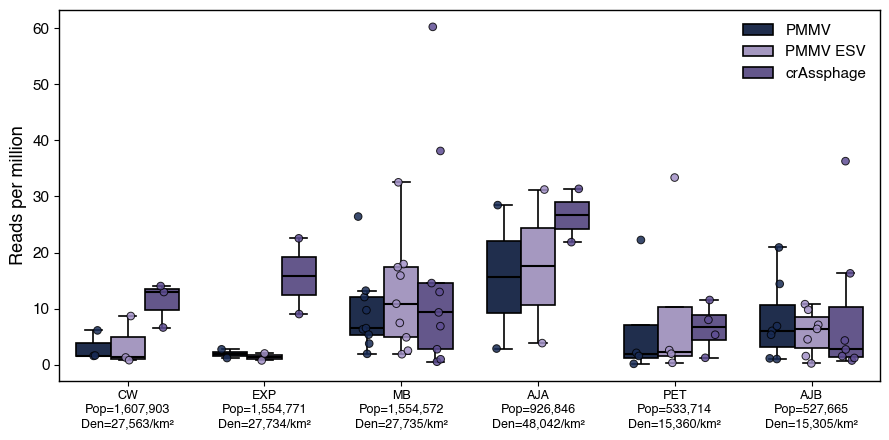

In [42]:

import seaborn as sns

pop_density = {canal: pop_catchment[canal] / area_sqkm[canal] for canal in pop_catchment}

plot_df = indidf.melt( id_vars=["sample", "canal"], value_vars=["PMMV_RPM", "PPMV_RPM_ESV", "crAss_RPM"], var_name="marker", value_name="RPM")

plot_df["marker"] = plot_df["marker"].replace({ "PMMV_RPM": "PMMV",  "PPMV_RPM_ESV": "PMMV ESV",  "crAss_RPM": "crAssphage"})
plot_df = plot_df.dropna(subset=["canal", "marker", "RPM"])
m_ord = ["PMMV", "PMMV ESV", "crAssphage"]

m_col = { "PMMV": "#182b55", "PMMV ESV": "#a291c7", "crAssphage": "#5f4e94"}

fig, ax = plt.subplots(figsize=(9, 4.5))

sns.boxplot( data=plot_df, x="canal", y="RPM", hue="marker", order=canal_order, hue_order=m_ord, palette=m_col, width=0.75, showfliers=False, linewidth=1.2, boxprops={"edgecolor": "black"},medianprops={"color": "black", "linewidth": 1.5}, whiskerprops={"color": "black", "linewidth": 1.2}, capprops={"color": "black", "linewidth": 1.2}, ax=ax)

sns.stripplot( data=plot_df, x="canal",y="RPM",hue="marker", order=canal_order,hue_order=m_ord,dodge=True,palette=m_col,size=5.5,edgecolor="black",linewidth=0.7,alpha=0.85, jitter=0.15, ax=ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(  handles[:3],  labels[:3],  title="", frameon=False,fontsize=11)

ax.set_xticklabels([ f"{canal}\nPop={pop_catchment[canal]:,}\nDen={pop_density[canal]:,.0f}/km²" for canal in canal_order])
ax.set_xlabel("")
ax.set_ylabel("Reads per million", fontsize=13)

ax.tick_params(axis="x", labelsize=9, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1)

ax.grid(False)

plt.tight_layout()

plt.show()

In [44]:
m_summ = (indidf.groupby("canal", as_index=False).agg( PMMV_median_RPM=("PMMV_RPM", "median"), crAss_median_RPM=("crAss_RPM", "median"), PMMV_mean_RPM=("PMMV_RPM", "mean"), crAss_mean_RPM=("crAss_RPM", "mean"),n_samples=("sample", "nunique")))


,canal,PMMV_median_RPM,crAss_median_RPM,PMMV_mean_RPM,crAss_mean_RPM,n_samples,PMMV_rank,crAss_rank,rank_difference
0,AJA,15.679652,26.606976,15.679652,26.606976,2,1.0,1.0,0.0
3,EXP,1.994226,15.795528,1.994226,15.795528,2,4.0,2.0,2.0
2,CW,1.667786,12.977809,3.135927,11.222688,3,6.0,3.0,3.0
4,MB,6.542850,9.346929,9.497988,16.272338,9,2.0,4.0,-2.0
5,PET,1.865694,6.693506,6.540727,6.551961,4,5.0,5.0,0.0
1,AJB,6.062218,2.749101,7.980980,9.035713,7,3.0,6.0,-3.0


In [43]:
pathogens=['Mamastrovirus 1', 'Human mastadenovirus F', 'Aichivirus A',
                     'Norwalk virus','Human mastadenovirus D',
            'Human mastadenovirus C',            'Human mastadenovirus A',
                   'Astrovirus MLB1',              'Human polyomavirus 1',
                  'Human astrovirus', 'Human mastadenovirus B',
    'Human gammaherpesvirus 4',                     'Salivirus FHB', 'Norovirus GII'
    'HMO Astrovirus A',
                       'Salivirus A', 'Human adenovirus 7', 'Norovirus GII',       'Norovirus GII.17',          'Norovirus GIV',
        'Norovirus GII.2',           'Norovirus GI',        'Norovirus GIV.1',
 'Norovirus GII isolates']

In [44]:
len(MT[MT["rank"]=="species"]["taxName"].unique())-len(others)-len(pathogens)/ len(MT[MT["rank"]=="species"]["taxName"].unique())

81.73863636363636

In [45]:
sdf=MT[MT['taxName'].isin(pathogens)]

In [46]:
sdf["taxName"].unique()

<ArrowStringArray>
[         'Mamastrovirus 1',   'Human mastadenovirus F',
             'Aichivirus A',            'Norwalk virus',
            'Norovirus GII',   'Human mastadenovirus D',
   'Human mastadenovirus C',   'Human mastadenovirus A',
          'Astrovirus MLB1',     'Human polyomavirus 1',
         'Human astrovirus',   'Human mastadenovirus B',
 'Human gammaherpesvirus 4',            'Salivirus FHB',
              'Salivirus A',       'Human adenovirus 7']
Length: 16, dtype: str

In [47]:
viral_families = {    "Human mastadenovirus F": "Adenoviridae",    "Human mastadenovirus D": "Adenoviridae",    "Mamastrovirus 1": "Astroviridae",    "adeno-associated virus 2": "Parvoviridae",    "Human mastadenovirus C": "Adenoviridae",    "Human mastadenovirus B": "Adenoviridae",     "Human polyomavirus 1": "Polyomaviridae",    "Mastadenovirus": "Adenoviridae",    "Human adenovirus 7": "Adenoviridae",    "Human adenovirus 54": "Adenoviridae", "Aichivirus A	": "Picornaviridae",  "Aichi virus 1": "Picornaviridae",    "Salivirus FHB": "Picornaviridae",    "Human astrovirus": "Astroviridae",    "Human mastadenovirus A": "Adenoviridae",    "Astrovirus MLB1": "Astroviridae",    "Human adenovirus 5": "Adenoviridae", "Norwalk virus": "Caliciviridae",   "Norovirus GII": "Caliciviridae",    "Severe acute respiratory syndrome coronavirus 2": "Coronaviridae",    "Human bocavirus 3": "Parvoviridae", "Aichivirus A": "Picornaviridae",    "Aichivirus A1": "Picornaviridae", "Salivirus A":"Picornaviridae",   "Human gammaherpesvirus 4": "Herpesviridae",    "Sapporo virus": "Caliciviridae",    "Enterovirus C": "Picornaviridae",    "JC polyomavirus": "Polyomaviridae",    "Hepatovirus A": "Picornaviridae",    "HMO Astrovirus A": "Astroviridae",    "Kobuvirus": "Picornaviridae",    "Human herpesvirus 4 type 2": "Herpesviridae"}
sdf["family"]=sdf["taxName"].map(viral_families)
viral_genera = {'Aichi virus 1': 'Kobuvirus', 'Aichivirus A':'Kobuvirus', 'Astrovirus MLB1': 'Mamastrovirus', 'Human polyomavirus 1': 'Betapolyomavirus', 'Enterovirus C': 'Enterovirus', 'HMO Astrovirus A': 'Mamastrovirus', 'Hepatovirus A': 'Hepatovirus', 'Human adenovirus 5': 'Mastadenovirus', 'Human adenovirus 54': 'Mastadenovirus', 'Human adenovirus 7': 'Mastadenovirus', 'Human astrovirus': 'Mamastrovirus', 'Human bocavirus 3': 'Bocaparvovirus', 'Human gammaherpesvirus 4': 'Lymphocryptovirus', 'Human herpesvirus 4 type 2': 'Lymphocryptovirus', 'Human mastadenovirus A': 'Mastadenovirus', 'Human mastadenovirus B': 'Mastadenovirus', 'Human mastadenovirus C': 'Mastadenovirus', 'Human mastadenovirus D': 'Mastadenovirus', 'Human mastadenovirus F': 'Mastadenovirus', 'JC polyomavirus': 'Betapolyomavirus', 'Kobuvirus': 'Kobuvirus', 'Mamastrovirus 1': 'Mamastrovirus', 'Mastadenovirus': 'Mastadenovirus', 'Norwalk virus': 'Norovirus', 'Norovirus GII': 'Norovirus', 'Norovirus GII.2': 'Norovirus', 'Salivirus A': 'Salivirus', 'Salivirus FHB': 'Salivirus', "Salivirus NG-J1'Sapovirus Hu/Dresden/pJG-Sap01/DE": 'Salivirus', 'Sapporo virus': 'Sapovirus', 'Severe acute respiratory syndrome coronavirus 2': 'Betacoronavirus', 'adeno-associated virus 2': 'Dependoparvovirus', 'aichivirus A1': 'Kobuvirus'}
sdf["genus"]=sdf["taxName"].map(viral_genera)


In [49]:
sdf["kmerthreshold"]=sdf["sample"].map(kmer)
sdf["kmerthreshold_strict"]=sdf["sample"].map(kmer_strict_d)
sdf["pass"]=sdf["kmers"]> sdf["kmerthreshold"]
sdf["pass_strict"]=sdf["kmers"]> sdf["kmerthreshold_strict"]

In [50]:
sdf[sdf["taxName"].str.contains("Norwa")]

,%,reads,taxReads,kmers,dup,cov,taxID,rank,taxName,sample,family,genus,kmerthreshold,kmerthreshold_strict,pass,pass_strict
10514,0.002090,109,0,1198,5.01,0.008591,11983,species,Norwalk virus,MB_UPS_2A,Caliciviridae,Norovirus,3300.0,6500.0,False,False
12163,0.002865,226,2,1580,8.06,0.011330,11983,species,Norwalk virus,MB_UPS_3A,Caliciviridae,Norovirus,5280.0,10400.0,False,False
10919,0.002781,238,0,1386,9.09,0.009940,11983,species,Norwalk virus,MBD_DWS_2C,Caliciviridae,Norovirus,5940.0,11700.0,False,False
9790,0.001978,143,0,1034,8.81,0.007415,11983,species,Norwalk virus,AJA_2A,Caliciviridae,Norovirus,4620.0,9100.0,False,False
9570,0.001140,81,0,925,4.17,0.006634,11983,species,Norwalk virus,MB_MDS_3B,Caliciviridae,Norovirus,4620.0,9100.0,False,False
8187,0.000920,68,0,950,3.85,0.006813,11983,species,Norwalk virus,AJA_3A,Caliciviridae,Norovirus,4620.0,9100.0,False,False
9347,0.014040,355,0,1612,16.20,0.011560,11983,species,Norwalk virus,EXP_UPS_1A,Caliciviridae,Norovirus,1980.0,3900.0,False,False


In [51]:
bcgdf=pd.read_csv("ESVIRITU_viral_relative_abundance.csv").rename(columns={"sample_ID":"sample", "read_count":"ESV_reads",  "rel_abundance":"ESV_rel_abundance",   "genus_plot":"family"})

In [55]:
gdf = sdf.groupby(['sample', 'family'], as_index=False)['reads'].sum()
tp_gen = gdf.groupby('family')['reads'].sum().sort_values(ascending=False).head(15).index
gdf['genus_plot'] = np.where(gdf['family'].isin(tp_gen),gdf['family'],'Other')
gdf = gdf.groupby(['sample', 'genus_plot'], as_index=False)['reads'].sum()

gdf['rel_abundance'] = (gdf.groupby('sample')['reads'].transform(lambda x: x / x.sum()))
gdf=gdf.rename(columns={"reads":"KU_reads", "rel_abundance":"KU_rel_abundance", "genus_plot":"family"})

merged_gdf = gdf.merge(bcgdf,on=["sample", "family"],how="outer"  )
merged_gdf=merged_gdf[~merged_gdf["family"].isin(["Dicistroviridae"])]
merged_gdf["family"]=merged_gdf["family"].str.replace("Herpesviridae", "Orthoherpesviridae")

In [56]:
merged_gdf["family"].unique()

<ArrowStringArray>
[      'Adenoviridae',       'Astroviridae',      'Caliciviridae',
       'Parvoviridae',     'Picornaviridae',     'Polyomaviridae',
 'Orthoherpesviridae']
Length: 7, dtype: str

In [57]:
for fam in ['Adenoviridae', 'Astroviridae', 'Picornaviridae']:
    KU=merged_gdf[merged_gdf["family"]==fam]["KU_rel_abundance"].mean()
    ESV=merged_gdf[merged_gdf["family"]==fam]["ESV_rel_abundance"].mean()
    print(KU, ESV, (KU+ESV)/2)

0.6390463573617253 0.6037222397157206 0.621384298538723
0.268274459584557 0.36215656273210906 0.315215511158333
0.22138905585042556 0.03474989130196851 0.12806947357619702


In [58]:
merged_gdf["dates"]=merged_gdf["sample"].str.replace("_", "").map(dates)

In [60]:
merged_gdf[0:4]

,sample,family,KU_reads,KU_rel_abundance,Unnamed: 0,ESV_reads,ESV_rel_abundance,dates
0,AJA_1A,Adenoviridae,53.0,0.182131,0.0,112.0,0.176935,2024-07-25
1,AJA_1A,Astroviridae,238.0,0.817869,1.0,521.0,0.823065,2024-07-25
2,AJA_2A,Adenoviridae,2076.0,0.356211,2.0,4919.0,0.359629,2024-08-01
3,AJA_2A,Astroviridae,2885.0,0.495024,3.0,8178.0,0.597894,2024-08-01


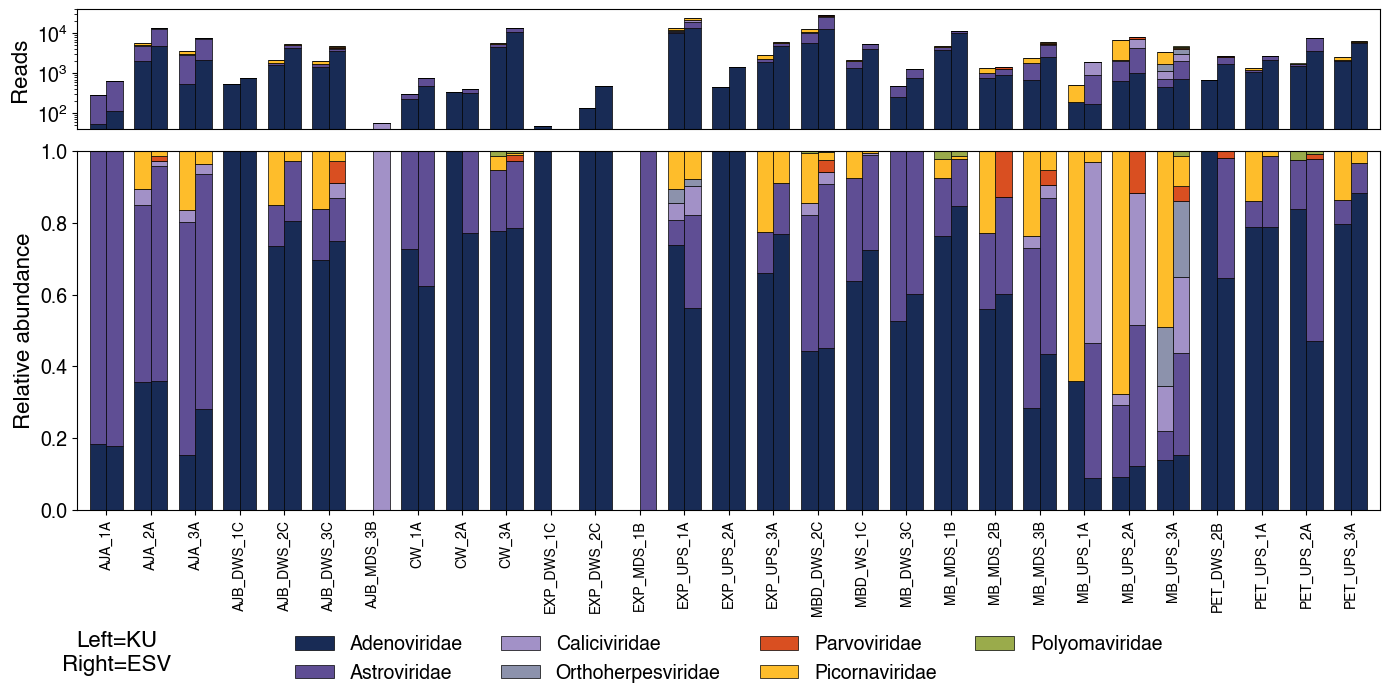

In [66]:

gdf = merged_gdf.groupby(['sample', 'family'], as_index=False)[['KU_reads', 'ESV_reads']].sum()
gdf['KU_rel_abundance'] = gdf.groupby('sample')['KU_reads'].transform(lambda x: x / x.sum())
gdf['ESV_rel_abundance'] = gdf.groupby('sample')['ESV_reads'].transform(lambda x: x / x.sum())
piv_ku_abs = gdf.pivot(index='sample', columns='family', values='KU_reads').fillna(0)
piv_bc_abs =gdf.pivot(index='sample', columns='family', values='ESV_reads').fillna(0)
piv_ku_rel = gdf.pivot(index='sample', columns='family', values='KU_rel_abundance').fillna(0)
piv_bc_rel = gdf.pivot(index='sample', columns='family', values='ESV_rel_abundance').fillna(0)
samples = piv_ku_abs.index
families = piv_ku_abs.columns
    piv_bc_abs = piv_bc_abs.reindex(index=samples, columns=families, fill_value=0)
piv_ku_rel = piv_ku_rel.reindex(index=samples, columns=families, fill_value=0)
piv_bc_rel = piv_bc_rel.reindex(index=samples, columns=families, fill_value=0)

color_dict = {'Adenoviridae': '#182b55', 'Astroviridae': '#5f4e94', 'Caliciviridae': '#a291c7', 'Coronaviridae': '#900c3f', 'Herpesviridae': '#82cbec', 'Parvoviridae': '#d94f21', 'Picornaviridae': '#febd2b','Polyomaviridae': '#9aab4b'}
ec = [ "#8C92AC", "#9b2226", "#6a4c93", "#1982c4","#8ac926", "#ff595e","#FFFDD0", "#ffca3a", "#8338ec", "#3a86ff"]

family_list = list(families)
color_map = color_dict.copy()
extra_idx = 0
for family in family_list:
    if family not in color_map:
        color_map[family] = ec[extra_idx % len(ec)]
        extra_idx += 1

fig, (ax_top, ax_bottom) = plt.subplots(2, 1,figsize=(14, 7),sharex=True,gridspec_kw={"height_ratios": [1, 3]})
x = np.arange(len(samples)) * 2.3
bar_width = 0.85
x_ku = x - bar_width / 2
x_bc = x + bar_width / 2

bottom_ku = np.zeros(len(samples))
bottom_bc = np.zeros(len(samples))

for family in family_list:
    ku_vals = piv_ku_abs[family].values
    bc_vals = piv_bc_abs[family].values
    ax_top.bar(x_ku,ku_vals, width=bar_width,bottom=bottom_ku,color=color_map[family], edgecolor="black", linewidth=0.5)
    ax_top.bar( x_bc, bc_vals,  width=bar_width, bottom=bottom_bc, color=color_map[family],edgecolor="black", linewidth=0.5)
    bottom_ku += ku_vals
    bottom_bc += bc_vals

ax_top.set_yscale("log")
ax_top.set_ylabel("Reads", fontsize=16)
ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax_top.margins(x=0.01)
ax_top.tick_params(axis="y", labelsize=14)


bottom_ku = np.zeros(len(samples))
bottom_bc = np.zeros(len(samples))

for family in family_list:
    ku_vals = piv_ku_rel[family].values
    bc_vals = piv_bc_rel[family].values
    ax_bottom.bar( x_ku,ku_vals,width=bar_width,bottom=bottom_ku,color=color_map[family],label=family, edgecolor="black", linewidth=0.5)
    ax_bottom.bar( x_bc, bc_vals,width=bar_width, bottom=bottom_bc, color=color_map[family], edgecolor="black",linewidth=0.5)
    bottom_ku += ku_vals
    bottom_bc += bc_vals

ax_bottom.set_ylabel("Relative abundance", fontsize=16)
ax_bottom.set_ylim(0, 1)
ax_bottom.set_xticks(x)
ax_bottom.set_xticklabels(samples, rotation=90, fontsize=10)
ax_bottom.tick_params(axis="y", labelsize=14)
ax_bottom.margins(x=0.01)

n_items = len(family_list)
ncol = int(np.ceil(n_items / 2))

ax_bottom.legend( loc="upper center", bbox_to_anchor=(0.5, -0.3), ncol=ncol, frameon=False, fontsize=14)
ax_bottom.text(0.03, -0.4, "Left=KU\nRight=ESV",ha="center",va="center",transform=ax_bottom.transAxes,fontsize=16)
plt.subplots_adjust(hspace=0.05, bottom=0.25)



plt.tight_layout()

In [67]:


df = gdf.copy()
df["KU_rel_abundance"] = pd.to_numeric(df["KU_rel_abundance"], errors="coerce").fillna(0)
df["ESV_rel_abundance"] = pd.to_numeric(df["ESV_rel_abundance"], errors="coerce").fillna(0)

df = df.groupby(["sample", "family"], as_index=False).agg({"KU_rel_abundance": "sum","ESV_rel_abundance": "sum"})

def com_s(subdf):
    ku = subdf["KU_rel_abundance"].to_numpy(dtype=float)
    esv = subdf["ESV_rel_abundance"].to_numpy(dtype=float)
    ku = ku / ku.sum() if ku.sum() > 0 else ku
    esv = esv / esv.sum() if esv.sum() > 0 else esv
    bc = braycurtis(ku, esv)
    if np.std(ku) > 0 and np.std(esv) > 0:
        rho, p = spearmanr(ku, esv)
    else:
        rho, p = np.nan, np.nan

    return pd.Series({
        "n_families": len(subdf),
        "bray_curtis": bc,
        "spearman_rho": rho,
        "spearman_p": p
    })

s_a = df.groupby("sample").apply(com_s).reset_index()

s_a

,sample,n_families,bray_curtis,spearman_rho,spearman_p
0,AJA_1A,2.0,0.005195,1.000000,NaN
1,AJA_2A,5.0,0.119594,0.900000,0.037386
2,AJA_3A,4.0,0.134698,0.800000,0.200000
3,AJB_DWS_1C,1.0,0.000000,NaN,NaN
4,AJB_DWS_2C,3.0,0.124688,0.500000,0.666667
5,AJB_DWS_3C,5.0,0.154607,0.359092,0.552815
6,AJB_MDS_3B,1.0,1.000000,NaN,NaN
7,CW_1A,2.0,0.103977,1.000000,NaN
8,CW_2A,2.0,0.228365,1.000000,NaN
9,CW_3A,5.0,0.040377,0.700000,0.188120


In [68]:
overall_summary = s_a["bray_curtis"].describe()
median_bc = s_a["bray_curtis"].median()
q1_bc = s_a["bray_curtis"].quantile(0.25)
q3_bc = s_a["bray_curtis"].quantile(0.75)

median_spearman = s_a["spearman_rho"].median()

print(f"Median Bray-Curtis dissimilarity: {median_bc:.3f}")
print(f"IQR: {q1_bc:.3f}-{q3_bc:.3f}")
print(f"Median Spearman rho: {median_spearman:.3f}")

Median Bray-Curtis dissimilarity: 0.134
IQR: 0.094-0.353
Median Spearman rho: 0.700


In [70]:
sdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in sdf["sample"]]

In [71]:
gdf = sdf.groupby(['canal', 'family'], as_index=False)['reads'].sum()
top_g = gdf.groupby('family')['reads'].sum().sort_values(ascending=False).head(15).index
gdf['genus_plot'] = np.where(gdf['family'].isin(top_g),gdf['family'],'Other')
gdf = gdf.groupby(['canal', 'genus_plot'], as_index=False)['reads'].sum()
gdf['rel_abundance'] = gdf.groupby('canal')['reads'].transform(lambda x: x / x.sum())


In [72]:

c_t = gdf.pivot_table(index="canal",columns="genus_plot",values="reads",aggfunc="sum",fill_value=0)

c_t

genus_plot,Adenoviridae,Astroviridae,Caliciviridae,Herpesviridae,Picornaviridae,Polyomaviridae
canal,,,,,,
AJA,2675,5466,369,0,1210,0
AJB,3543,532,0,0,654,0
CW,5093,1078,0,0,225,74
EXP,12557,1259,659,523,2080,0
MB,13833,9550,1146,551,9691,189
PET,5272,519,0,0,529,43


In [ ]:
chi2, p, dof, expected = chi2_contingency(c_t)

In [75]:
sdf.groupby("family")["reads"].sum().sort_values(ascending=False).head(10)

family
Adenoviridae      42973
Astroviridae      18404
Picornaviridae    14389
Caliciviridae      2174
Herpesviridae      1074
Polyomaviridae      306
Name: reads, dtype: int64

In [76]:
sdf.groupby("genus")["reads"].sum().sort_values(ascending=False).head(10)

genus
Mastadenovirus       42973
Mamastrovirus        18404
Kobuvirus            12029
Salivirus             2360
Norovirus             2174
Lymphocryptovirus     1074
Betapolyomavirus       306
Name: reads, dtype: int64

In [78]:
sdf.groupby("taxName")["taxReads"].sum().sort_values(ascending=False).head(30)

taxName
Human mastadenovirus F      35916
Mamastrovirus 1             12196
Human astrovirus             5255
Human mastadenovirus D       3354
Salivirus FHB                2259
Human gammaherpesvirus 4      915
Human mastadenovirus A        761
Human mastadenovirus C        378
Norovirus GII                 316
Human polyomavirus 1          306
Human adenovirus 7            200
Human mastadenovirus B         54
Salivirus A                    10
Astrovirus MLB1                 8
Norwalk virus                   2
Aichivirus A                    0
Name: taxReads, dtype: int64

In [82]:
s_c = sdf.groupby("taxName")["sample"].count().reset_index(name="Relaxed")
s_c.to_csv("KUmin_virusdetection_counts.csv", index=None)

passdf=sdf[sdf["pass"]==True]
s_c = passdf.groupby("taxName")["sample"].count().reset_index(name="Balanced")
s_c.to_csv("KUmax_virusdetection_counts.csv", index=None)

passd_strict=sdf[sdf["pass_strict"]==True]
s_c = passdf.groupby("taxName")["sample"].count().reset_index(name="Strict")
s_c.to_csv("KUmax_virusvalidation_counts.csv", index=None)

In [84]:
ESV=pd.read_csv("Esviritu_virusvalidation_counts.csv").rename(columns={"Name":"taxName", "n_unique_sample_IDs":"ESV"})
KU_s=pd.read_csv('KUmax_virusdetection_counts.csv')
KU=pd.read_csv('KUmin_virusdetection_counts.csv')
KU_stricter=pd.read_csv('KUmax_virusvalidation_counts.csv')
merged_df = ESV.merge(KU, on="taxName", how="outer").merge(KU_s, on="taxName", how="outer").merge(KU_stricter, on="taxName", how="outer").fillna(0)
cols = ["ESV", "Relaxed", "Balanced", "Strict"]
merged_df.loc[merged_df["taxName"] == "BK virus",cols] = (merged_df.loc[merged_df["taxName"] == "BK virus", cols].values +merged_df.loc[merged_df["taxName"] == "Human polyomavirus 1", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Human polyomavirus 1"]
merged_df.loc[merged_df["taxName"] == "Norovirus",cols] = (merged_df.loc[merged_df["taxName"] == "Norovirus", cols].values +merged_df.loc[merged_df["taxName"] == "Norovirus GII", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Norovirus GII"]
merged_df.loc[merged_df["taxName"] == "Norovirus",cols] = (merged_df.loc[merged_df["taxName"] == "Norovirus", cols].values +merged_df.loc[merged_df["taxName"] == "Norwalk virus", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Norwalk virus"]
merged_df.loc[ merged_df["taxName"] == "Salivirus A",cols] = (merged_df.loc[merged_df["taxName"] == "Salivirus A", cols].values +merged_df.loc[merged_df["taxName"] == "Salivirus FHB", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Salivirus FHB"]
merged_df.loc[merged_df["taxName"] == "EBV",cols] = (merged_df.loc[merged_df["taxName"] == "EBV", cols].values +merged_df.loc[merged_df["taxName"] == "Human gammaherpesvirus 4", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Human gammaherpesvirus 4"]
merged_df=merged_df[~merged_df["taxName"].isin(["Human astrovirus"])]
merged_df = merged_df.reset_index(drop=True)

merged_df=merged_df[~merged_df["taxName"].isin(["Canine kobuvirus"]) ]
merged_df["taxName"]=merged_df["taxName"].str.replace("Human adenovirus ", "HAdV-").str.replace("Human mastadenovirus ", "HAdV-").replace("Severe acute respiratory syndrome coronavirus 2", "SARS-CoV-2")
merged_df["taxName"]=merged_df["taxName"].str.replace("adeno-associated virus 2", "AAV2").replace("Betapolyomavirus hominis", "BK virus")
merged_df["taxName"]=merged_df["taxName"].str.replace("Human gammaherpesvirus 4", "EBV").replace("Human coronavirus OC43", "OC43")
merged_df.loc[merged_df["taxName"] == "NC-astro",cols] = (merged_df.loc[merged_df["taxName"] == "NC-astro", cols].values +merged_df.loc[merged_df["taxName"] == "Astrovirus MLB1", cols].values)
merged_df = merged_df[merged_df["taxName"] != "Astrovirus MLB1"]


In [85]:
merged_df

,taxName,ESV,Relaxed,Balanced,Strict
0,AAV2,10.0,0.0,0.0,0.0
1,Aichivirus A,0.0,17.0,0.0,0.0
3,BK virus,4.0,4.0,0.0,0.0
4,EBV,2.0,2.0,2.0,2.0
5,Enterovirus A,1.0,0.0,0.0,0.0
6,Enterovirus C,3.0,0.0,0.0,0.0
7,HAdV-7,0.0,1.0,0.0,0.0
8,HAdV-A,10.0,5.0,0.0,0.0
9,HAdV-B,2.0,3.0,0.0,0.0
10,HAdV-C,5.0,4.0,0.0,0.0


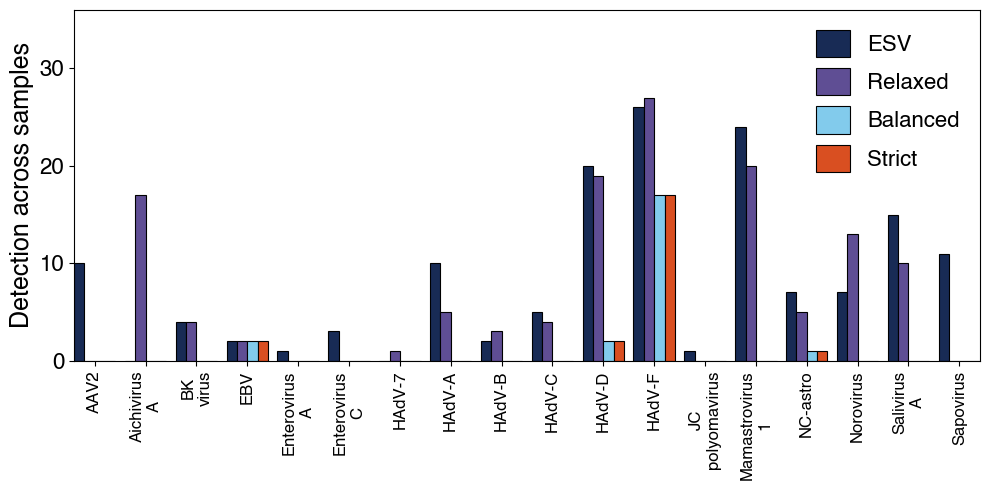

In [89]:

merged_df = merged_df.sort_values("taxName")
xlabels = merged_df["taxName"].str.replace(" ", "\n", regex=False)


width = 0.22
group_gap = 0.2   

x = np.arange(len(merged_df["taxName"])) * (4 * width + group_gap)
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x,merged_df["ESV"],width,label="ESV",color="#182b55",edgecolor="black",linewidth=0.8)
ax.bar(x + width,merged_df["Relaxed"],width,label="Relaxed",color="#5f4e94",edgecolor="black",linewidth=0.8)
ax.bar(x + 2 * width,merged_df["Balanced"],width,label="Balanced",color="#82cbec",edgecolor="black",linewidth=0.8)
ax.bar(x + 3 * width,merged_df["Strict"],width,label="Strict",color="#d94f21",edgecolor="black",linewidth=0.8)
plt.ylim(0, 36)

ax.set_xlabel("")
ax.set_ylabel("Detection across samples", fontsize=18)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(xlabels, rotation=90, fontsize=12)
ax.tick_params(axis="y", labelsize=16)

ax.legend(frameon=False,fontsize=16,handlelength=1.5, handleheight=1.5)

ax.margins(x=0)
plt.tight_layout()


plt.show()

In [83]:
MTori[(MTori["taxName"].str.contains("Noro")) & (MTori["rank"]=="clade") & (MTori["kmers"]>=660)].sort_values("kmers", ascending=False)

,%,reads,taxReads,kmers,dup,cov,taxID,rank,taxName,sample
12164,0.002383,188,32,1507,7.77,0.03040,122929,clade,Norovirus GII,MB_UPS_3A
10515,0.001955,102,22,1158,4.99,0.02336,122929,clade,Norovirus GII,MB_UPS_2A
9348,0.012020,304,129,1104,21.30,0.02227,122929,clade,Norovirus GII,EXP_UPS_1A
10920,0.002360,202,70,948,8.91,0.01912,122929,clade,Norovirus GII,MBD_DWS_2C
9791,0.001467,106,54,705,9.91,0.01422,122929,clade,Norovirus GII,AJA_2A
8188,0.000704,52,9,705,4.29,0.01422,122929,clade,Norovirus GII,AJA_3A


In [85]:
MTori[(MTori["taxName"].str.contains("Sapo"))].sort_values("kmers", ascending=False)[0:10]

,%,reads,taxReads,kmers,dup,cov,taxID,rank,taxName,sample
9796,0.000968,70,0,427,7.69,0.008188,95341,genus,Sapovirus,AJA_2A
9562,0.001168,83,0,381,6.78,0.007306,95341,genus,Sapovirus,MB_MDS_3B
10572,0.001170,66,0,308,10.80,0.005906,95341,genus,Sapovirus,AJB_DWS_3C
9407,0.000465,27,0,269,5.71,0.005158,95341,genus,Sapovirus,MBD_WS_1C
9409,0.000414,24,2,257,5.89,0.017590,515177,no rank,Sapovirus GII,MBD_WS_1C
10380,0.000799,85,0,221,22.00,0.004238,95341,genus,Sapovirus,CW_3A
9801,0.000470,34,0,214,10.60,0.014140,280756,no rank,Sapovirus isolates,AJA_2A
9798,0.000498,36,0,213,4.80,0.014580,515177,no rank,Sapovirus GII,AJA_2A
9358,0.003361,85,0,211,10.70,0.004046,95341,genus,Sapovirus,EXP_UPS_1A
10383,0.000790,84,84,208,23.20,0.028120,291175,no rank,Sapovirus Hu/Dresden/pJG-Sap01/DE,CW_3A


In [86]:
MTori[(MTori["taxName"].str.contains("orona"))].sort_values("kmers", ascending=False)[0:10]

,%,reads,taxReads,kmers,dup,cov,taxID,rank,taxName,sample
10946,0.000257,22,3,601,5.49,0.000307,2501931,subfamily,Orthocoronavirinae,MBD_DWS_2C
10947,0.000222,19,0,600,5.49,0.000860,694002,genus,Betacoronavirus,MBD_DWS_2C
8890,0.000152,15,3,570,4.28,0.000291,2501931,subfamily,Orthocoronavirinae,AJB_DWS_2C
8891,0.000121,12,0,569,4.28,0.000815,694002,genus,Betacoronavirus,AJB_DWS_2C
8893,0.000111,11,0,499,4.71,0.003124,694009,species,Severe acute respiratory syndrome-related coro...,AJB_DWS_2C
8894,0.000111,11,11,497,4.71,0.017420,2697049,no rank,Severe acute respiratory syndrome coronavirus 2,AJB_DWS_2C
10952,0.000082,7,0,327,2.62,0.003572,694003,species,Betacoronavirus 1,MBD_DWS_2C
10603,0.000382,39,24,315,6.11,0.000161,2501931,subfamily,Orthocoronavirinae,EXP_MDS_1B
10604,0.000147,15,0,313,6.03,0.000448,694002,genus,Betacoronavirus,EXP_MDS_1B
9868,0.000459,44,0,277,31.10,0.000141,2501931,subfamily,Orthocoronavirinae,AJB_UPS_3A


In [87]:
pdf=sdf[(sdf["taxName"].str.contains("Human adenovirus 7")) & (sdf["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in pdf["sample"]]
pdf["date"]=[dates[re.sub("_", "", x)] for x in pdf["sample"]]
print(len(pdf["sample"].unique()))
print(len(pdf["canal"].unique()))
print(len(pdf["date"].unique()))

1
1
1


In [90]:
pdf=sdf[(sdf["taxName"].str.contains("Human mastadenovirus F")) & (sdf["kmers"]>=700)]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
pdf["canal"]=[re.sub("MBD", "MB", x.split("_")[0]) for x in pdf["sample"]]
pdf["date"]=[dates[re.sub("_", "", x)] for x in pdf["sample"]]
print(len(pdf["sample"].unique()))
print(len(pdf["canal"].unique()))
print(len(pdf["date"].unique()))

26
6
3


In [91]:
pdf["reads"] = pd.to_numeric(pdf["reads"], errors="coerce")
pdf["taxReads"] = pd.to_numeric(pdf["taxReads"], errors="coerce")
pdf["cov"] = pd.to_numeric(pdf["cov"], errors="coerce")
pdf["kmers"] = pd.to_numeric(pdf["kmers"], errors="coerce")
pdf["dup"] = pd.to_numeric(pdf["dup"], errors="coerce")
pdf["kmers_per_taxRead"] = pdf["kmers"] / pdf["taxReads"]
pdf["lineage_inflation"] = pdf["reads"] / pdf["taxReads"]
sizes = pdf["dup"] * 5
vmin = pdf["lineage_inflation"].min()
vmax = pdf["lineage_inflation"].max()
legend_dups = [pdf["dup"].quantile(0.25), pdf["dup"].median(),pdf["dup"].quantile(0.75)]

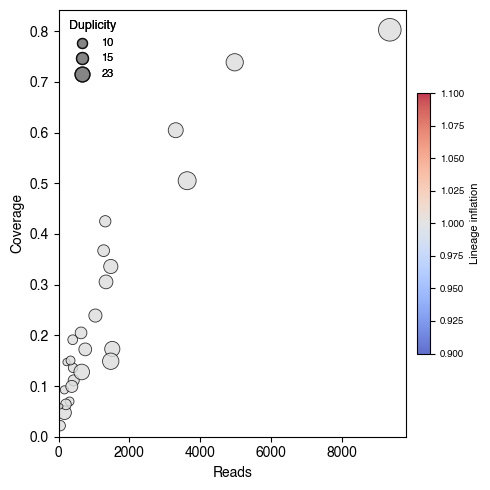

In [92]:

fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter(pdf["taxReads"], pdf["cov"], s=sizes, c=pdf["lineage_inflation"], cmap="coolwarm",vmin=vmin,vmax=vmax,edgecolor="black",linewidth=0.6, alpha=0.8)

ax.set_xlabel("Reads")
ax.set_ylabel("Coverage")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar( sc,ax=ax,fraction=0.035, pad=0.03,shrink=0.75)
cbar.set_label("Lineage inflation", fontsize=8)
cbar.ax.tick_params(labelsize=7)

handles = [ax.scatter( [],[], s=d * size_multiplier,color="grey",edgecolor="black", alpha=0.8 ) for d in legend_dups]

size_legend = ax.legend(handles, [f"{d:.0f}" for d in legend_dups], title="Duplicity", frameon=False, scatterpoints=1, loc="upper left", fontsize=8,title_fontsize=9)
ax.add_artist(size_legend)
plt.tight_layout()


plt.show()

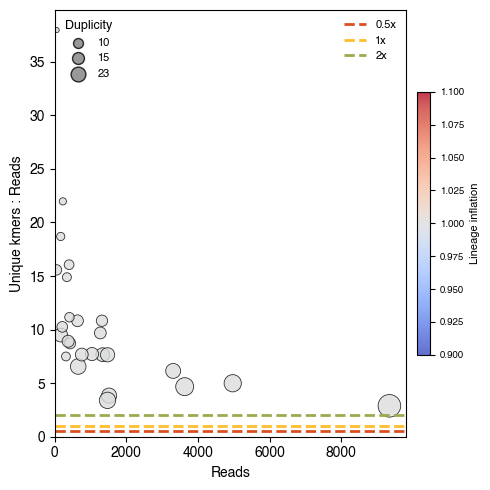

In [93]:

fig, ax = plt.subplots(figsize=(5, 5))

sc = ax.scatter(pdf["taxReads"], pdf["kmers_per_taxRead"],s=sizes,c=pdf["lineage_inflation"],cmap="coolwarm",vmin=vmin, vmax=vmax, edgecolor="black",linewidth=0.6,alpha=0.8)

ax.axhline(0.5,color="#d94f21",linestyle="--",linewidth=2,label="0.5x")
ax.axhline(1, color="#febd2b", linestyle="--", linewidth=2, label="1x")
ax.axhline(2,color="#9aab4b",linestyle="--",linewidth=2,label="2x")

ax.set_xlabel("Reads")
ax.set_ylabel("Unique kmers : Reads")

ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

cbar = plt.colorbar(sc,ax=ax,fraction=0.035,pad=0.03,shrink=0.75)
cbar.set_label("Lineage inflation", fontsize=8)
cbar.ax.tick_params(labelsize=7)

handles = [ax.scatter([],[],s=d * size_multiplier,color="grey",edgecolor="black",alpha=0.8  ) for d in legend_dups]

size_legend = ax.legend(handles,[f"{d:.0f}" for d in legend_dups], title="Duplicity",frameon=False,scatterpoints=1,loc="upper left",fontsize=8,title_fontsize=9)
ax.add_artist(size_legend)
line_legend = ax.legend(frameon=False,loc="upper right", fontsize=8)
plt.tight_layout()


plt.show()